In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import argparse
 
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry

In [11]:
parser = argparse.ArgumentParser()
parser.add_argument(
   '--input',
   default='places365/alley/Places365_val_00008196.jpg'
)
args, _ = parser.parse_known_args()


In [12]:
def show_anns(anns):
   if len(anns) == 0:
       return
   sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
   ax = plt.gca()
   ax.set_autoscale_on(False)
   for ann in sorted_anns:
       m = ann['segmentation']
       img = np.ones((m.shape[0], m.shape[1], 3))
       color_mask = np.random.random((1, 3)).tolist()[0]
       for i in range(3):
           img[:,:,i] = color_mask[i]
       np.dstack((img, m*0.35))
       ax.imshow(np.dstack((img, m*0.35)))

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/Places365_val_00008196.jpg'

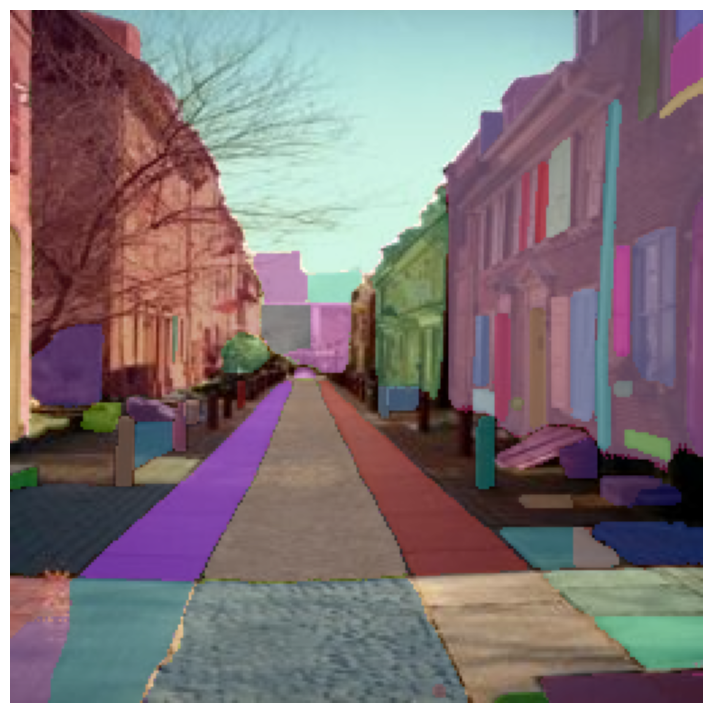

In [13]:
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.cuda()
mask_generator = SamAutomaticMaskGenerator(sam)
 
image_path = args.input
image_name = image_path.split(os.path.sep)[-1]
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
masks = mask_generator.generate(image)
plt.figure(figsize=(12, 9))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.savefig(os.path.join('outputs', image_name), bbox_inches='tight')